In [33]:
import numpy as np
import pandas as pd 

# sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import momepy
import os
import glob

Creating Samples

<>:124: SyntaxWarning: invalid escape sequence '\S'
<>:124: SyntaxWarning: invalid escape sequence '\S'
C:\Users\mmosh\AppData\Local\Temp\ipykernel_21588\671410882.py:124: SyntaxWarning: invalid escape sequence '\S'
  sample_output = f"{output_dir}\SamplePop.shp"
C:\Users\mmosh\AppData\Local\Temp\ipykernel_21588\671410882.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  Population['area'] = Population.geometry.area
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35043010601 of field tractsNM_9 of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35043010601 of field popul_bytr of feature 0 not successfully written. Possibly due to too larger num

  tractsNMnu tractsNM_1 tractsNM_2 tractsNM_3          tractsNM_4 tractsNM_5  \
0         35        001     003100         31     Census Tract 31      G5020   
1         35        001     004716      47.16  Census Tract 47.16      G5020   
2         35        001     004729      47.29  Census Tract 47.29      G5020   
3         35        001     003002      30.02  Census Tract 30.02      G5020   
4         35        001     002401      24.01  Census Tract 24.01      G5020   

   tractsNM_6  tractsNM_7          tractsNM_8    tractsNM_9  ...  popul_b_52  \
0    0.098744    0.000443  14000US35001003100  3.500100e+10  ...          62   
1    0.142304    0.000406  14000US35001004716  3.500100e+10  ...          40   
2    0.114773    0.000500  14000US35001004729  3.500100e+10  ...         153   
3    0.085818    0.000397  14000US35001003002  3.500100e+10  ...         119   
4    0.091297    0.000357  14000US35001002401  3.500100e+10  ...         123   

   popul_b_53  popul_b_54  popul_b_55 

c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35001003100 of field tractsNM_9 of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35001003100 of field popul_bytr of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35001004716 of field tractsNM_9 of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35001004716 of field popul_bytr of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\env

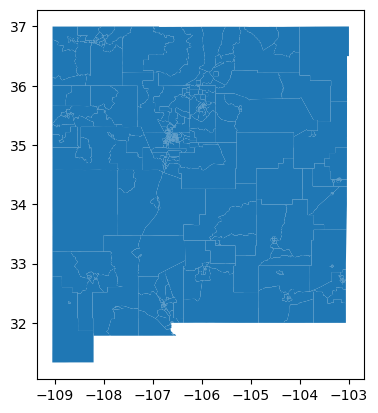

In [34]:
Population = gpd.read_file(r"C:\Users\mmosh\Research-Project\Population\popul_bytracts2018.shp").explode(
                ignore_index=True, index_parts=False
           )[["geometry"]] #explod here means we break multilines in GIS into multiple simple lines.
    
Population['area'] = Population.geometry.area
Population.plot()
# Possibly don't need what is above.
    
tracts = gpd.read_file("/Users/mmosh/Research-Project/Population/popul_bytracts2018.shp")

Sample1 = tracts[tracts['popul_by_1'] == 4883]

Sample1.to_file(r"C:\Users\mmosh\Research-Project\Population\Samples\S1_Pop.shp")

Sample2 = tracts[tracts['popul_by_1'] == 6839]

Sample2.to_file(r"C:\Users\mmosh\Research-Project\Population\Samples\S2_Pop.shp")
#Sample2.plot(edgecolor='black', color='lightgreen')

Sample3 = tracts[tracts['popul_by_1'] == 6809]

Sample3.to_file(r"C:\Users\mmosh\Research-Project\Population\Samples\S3_Pop.shp")
#Sample3.plot(edgecolor='black', color='lightgreen')

Sample4 = tracts[tracts['popul_by_1'] == 4303]

Sample4.to_file(r"C:\Users\mmosh\Research-Project\Population\Samples\S4_Pop.shp")
#Sample4.plot(edgecolor='black', color='lightgreen')

Sample5 = tracts[tracts['popul_by_1'] == 3573]

Sample5.to_file(r"C:\Users\mmosh\Research-Project\Population\Samples\S5_Pop.shp")
#Sample5.plot(edgecolor='black', color='lightgreen')

Sample6 = tracts[tracts['popul_by_1'] == 3510]

Sample6.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S6_Pop.shp')
#Sample6.plot(edgecolor='black', color='lightgreen')

Sample7 = tracts[tracts['popul_by_1'] == 6541]

Sample7.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S7_Pop.shp')
#Sample7.plot(edgecolor='black', color='lightgreen')

Sample8 = tracts[tracts['popul_by_1'] == 5195]

Sample8.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S8_Pop.shp')
#Sample8.plot(edgecolor='black', color='lightgreen')

Sample9 = tracts[tracts['popul_by_1'] == 4814]

Sample9.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S9_Pop.shp')
#Sample9.plot(edgecolor='black', color='lightgreen')

Sample10 = tracts[tracts['popul_by_1'] == 2699]

Sample10.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S10_Pop.shp')
#Sample10.plot(edgecolor='black', color='lightgreen')

Sample11 = tracts[tracts['popul_by_1'] == 1968]

Sample11.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S11_Pop.shp')
#Sample11.plot(edgecolor='black', color='lightgreen')

Sample12 = tracts[(tracts['popul_by_1'] == 3789) & (tracts['popul_by_2'] == 768)]

Sample12.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S12_Pop.shp')
#Sample12.plot(edgecolor='black', color='lightgreen')

Sample13 = tracts[tracts['popul_by_1'] == 4391]

Sample13.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S13_Pop.shp')
#Sample13.plot(edgecolor='black', color='red')

Sample14 = tracts[tracts['popul_by_1'] == 5270]

Sample14.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S14_Pop.shp')
#Sample14.plot(edgecolor='black', color='red')

Sample15 = tracts[tracts['popul_by_1'] == 3068]

Sample15.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S15_Pop.shp')
#Sample15.plot(edgecolor='black', color='red')

Sample16 = tracts[tracts['popul_by_1'] == 9017]

Sample16.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S16_Pop.shp')
#Sample16.plot(edgecolor='black', color='red')

Sample17 = tracts[tracts['popul_by_1'] == 2790] 

Sample17.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S17_Pop.shp')
#Sample17.plot(edgecolor='black', color='red')

Sample18 = tracts[tracts['popul_by_1'] == 5604]

Sample18.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S18_Pop.shp')
#Sample18.plot(edgecolor='black', color='red')

Sample19 = tracts[tracts['popul_by_1'] == 3322]

Sample19.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S19_Pop.shp')
#Sample19.plot(edgecolor='black', color='red')

Sample20 = tracts[tracts['popul_by_1'] == 4130]

Sample20.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S20_Pop.shp')
#Sample20.plot(edgecolor='black', color='red')

files = glob.glob("C:\\Users\\mmosh\\Research-Project\\Population\\Samples\\*.shp")
gdfs = [gpd.read_file(f) for f in files]

# Standardize CRS to NAD83 (EPSG:4269) for all GeoDataFrames
# This ensures compatibility before concatenation. This was done using the Copilot AI assistant in VS Code.
common_crs = "EPSG:4269"  # NAD83; change to "EPSG:4326" for WGS84 if preferred
gdfs = [gdf.to_crs(common_crs) if gdf.crs != common_crs else gdf for gdf in gdfs]

merged = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)

output_dir = r"C:\Users\mmosh\Research-Project\Population\Samples"
sample_output = f"{output_dir}\SamplePop.shp"
SamplePop = merged.to_file(sample_output)
SamplePop = gpd.read_file(sample_output)
print(SamplePop.head())



Adding In All Datasets

In [ ]:
#Adding Land Use data to sample populations base layer. 
from json import encoder

from sklearn.preprocessing import OneHotEncoder


Albaquerque_LandUse = gpd.read_file("C:\\Users\\mmosh\\Research-Project\\Land Use\\Albuq.shp")
Espanola_LandUse = gpd.read_file("C:\\Users\mmosh\\Research-Project\\Land Use\\aztec.shp")

files = glob.glob("C:\\Users\\mmosh\\Research-Project\\Land Use\\*.shp")
gdfs = [gpd.read_file(f) for f in files]

merged = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)
LU_dir = r"C:\Users\mmosh\Research-Project\Land Use\Combined"
LU_output = f"{LU_dir}\LandUse.shp"
merged.to_file(LU_output)

LandUse = gpd.read_file(LU_output)
LandUse.plot(edgecolor='black', color='red')
L_U = pd.Dataframe({
    "LUCODE": LandUse["11", "12", "13", "14", "15", "16", "17", "21", 2 "23", "24", "31", "32", "33", "41", "42", "43", "51", "52", "53", "54", "61", "62", "71", "72", "73", "74", "75", "76", "77", "81", "82", "83", "84", "91", "92",]
})

encoder1= OneHotEncoder(sparse=False)
encoded_array1= encoder.fit_transform(L_U[["LUCODE"]])

encoded_df = LandUse.Dataframe(
    encoded_array1,
    columns=encoder.get_feature_names_out(["LUCODE"])
)

print(encoded_df)

LandUse = LandUse.to_crs(SamplePop.crs)
joined1 = gpd.sjoin(SamplePop, LandUse, how="inner", predicate='intersects')
print(joined1.head())
joined1.to_file(r"C:\Users\mmosh\Research-Project\Tabulation\joined_output.shp")

#This is for when training and testing the data. 
#from sklearn.preprocessing import OneHotEncoder

#encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

#X_train_encoded = encoder.fit_transform(X_train[["categorical_column"]])

#X_test_encoded = encoder.transform(X_test[["categorical_column"]])

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\L'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\L'
C:\Users\mmosh\AppData\Local\Temp\ipykernel_21588\2425251110.py:8: SyntaxWarning: invalid escape sequence '\m'
  Espanola_LandUse = gpd.read_file("C:\\Users\mmosh\\Research-Project\\Land Use\\aztec.shp")
C:\Users\mmosh\AppData\Local\Temp\ipykernel_21588\2425251110.py:18: SyntaxWarning: invalid escape sequence '\L'
  LU_output = f"{LU_dir}\LandUse.shp"


SyntaxError: invalid syntax. Perhaps you forgot a comma? (2425251110.py, line 24)